In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.metrics import confusion_matrix



In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [4]:
df.tail()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
165029,165029,15667085,Meng,667,Spain,Female,33.0,2,0.0,1,1.0,1.0,131834.75,0
165030,165030,15665521,Okechukwu,792,France,Male,35.0,3,0.0,1,0.0,0.0,131834.45,0
165031,165031,15664752,Hsia,565,France,Male,31.0,5,0.0,1,1.0,1.0,127429.56,0
165032,165032,15689614,Hsiung,554,Spain,Female,30.0,7,161533.0,1,0.0,1.0,71173.03,0
165033,165033,15732798,Ulyanov,850,France,Male,31.0,1,0.0,1,1.0,0.0,61581.79,1


In [5]:
df.shape

(165034, 14)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  str    
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  str    
 5   Gender           165034 non-null  str    
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), str(3)
memory usage: 17.6 MB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [9]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].unique())


Surname:
<StringArray>
['Okwudilichukwu',  'Okwudiliolisa',          'Hsueh',            'Kao',
      'Chiemenam',       'Genovese',         'Ch'ang',    'Chukwuebuka',
          'Manna',       'Cattaneo',
 ...
       'Galloway',          'Batty',        'Buckner',       'Morphett',
       'Humffray',      'Christmas',        'Ah Mouy',         'Aliyev',
         'McMinn',         'Elkins']
Length: 2797, dtype: str

Geography:
<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

Gender:
<StringArray>
['Male', 'Female']
Length: 2, dtype: str


C:\Users\O.R.G\AppData\Local\Temp\ipykernel_724\358977919.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [10]:
df["Exited"].value_counts()

Exited
0    130113
1     34921
Name: count, dtype: int64

In [11]:
df[["id", "CustomerId"]].nunique()

id            165034
CustomerId     23221
dtype: int64

In [12]:
df = df.drop(columns=["id", "CustomerId", "Surname"])

In [13]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [14]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


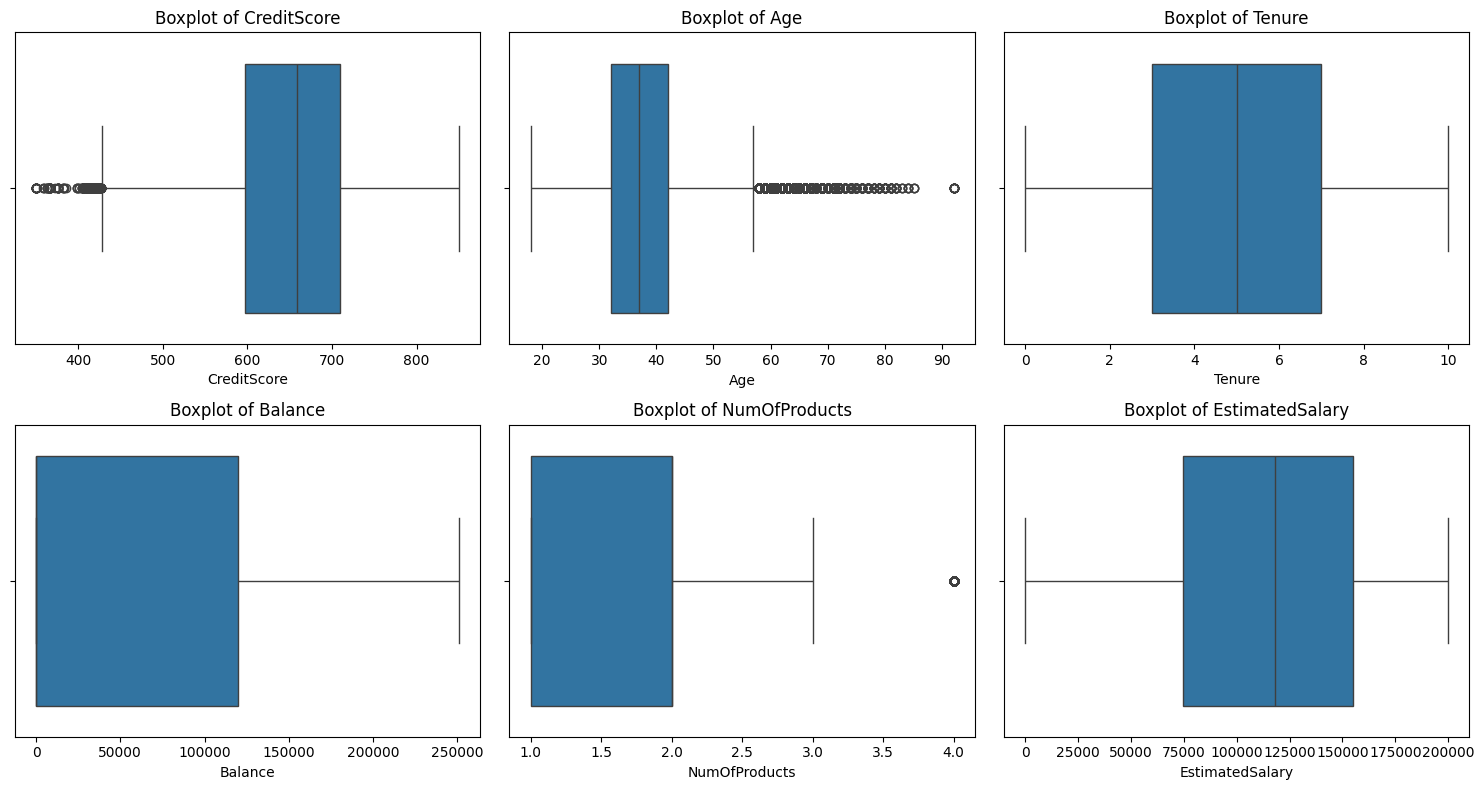

In [15]:
numeric_cols = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

Outliers were detected using the IQR method in Age (~3.9%), CreditScore (~0.15%) and NumOfProducts (~0.3%). They were kept because they are valid values, not data-entry errors, and they carry predictive signal (e.g. customers with 3-4 products churn at ~88%). Removing them would discard useful information.

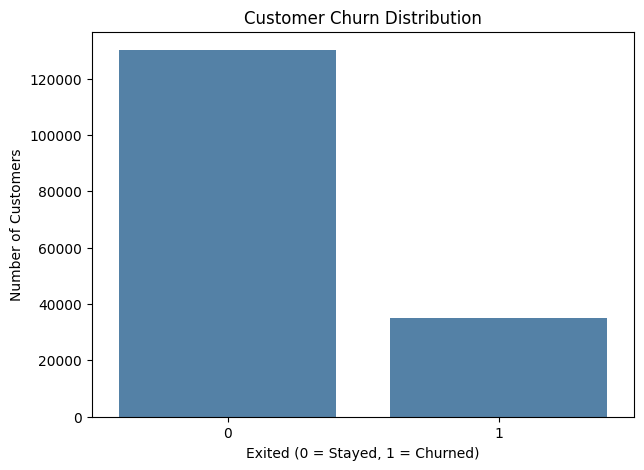

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Exited", color="steelblue")

plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.show()

The dataset is imbalanced, with a larger number of customers who stayed compared to those who churned. Therefore, evaluation metrics such as Precision, Recall, and F1-score should be considered alongside Accuracy.

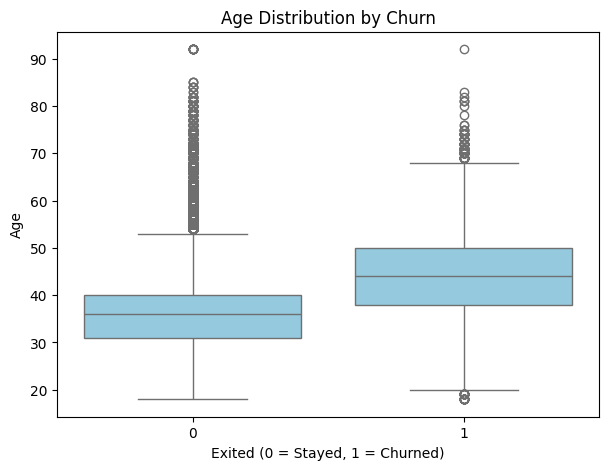

In [17]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x="Exited", y="Age", color="skyblue")

plt.title("Age Distribution by Churn")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Age")

plt.show()

Customers who churned tend to be older than customers who stayed, as shown by the higher median age. However, the age distributions overlap, indicating that age alone is not sufficient to predict customer churn.

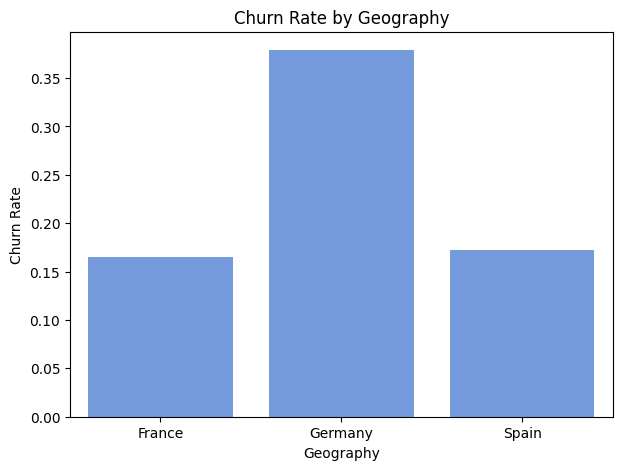

In [18]:
geo_rate = df.groupby("Geography", as_index=False)["Exited"].mean()

plt.figure(figsize=(7, 5))

sns.barplot(data=geo_rate, x="Geography", y="Exited", color="cornflowerblue")

plt.title("Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate")

plt.show()

Germany has a noticeably higher churn rate than France and Spain. France and Spain show relatively similar churn rates. This suggests that churn behavior varies across geographic groups, although geography alone does not explain why customers leave.

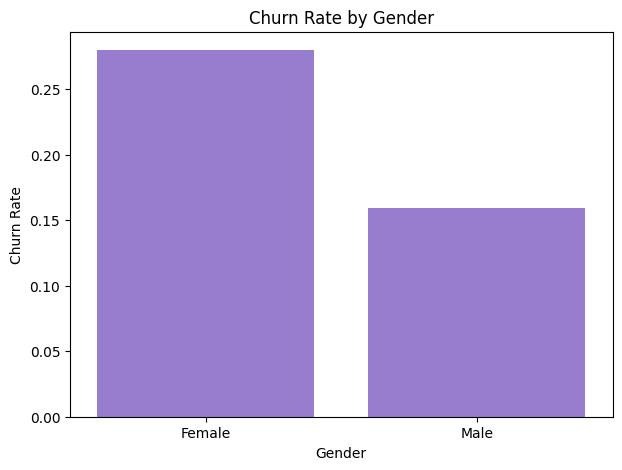

In [19]:
gender_rate = df.groupby("Gender", as_index=False)["Exited"].mean()

plt.figure(figsize=(7, 5))

sns.barplot(data=gender_rate, x="Gender", y="Exited", color="mediumpurple")

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate")


plt.show()

Female customers have a higher churn rate than male customers in this dataset. This indicates a difference in churn behavior between the two gender groups, although gender alone does not explain customer churn.

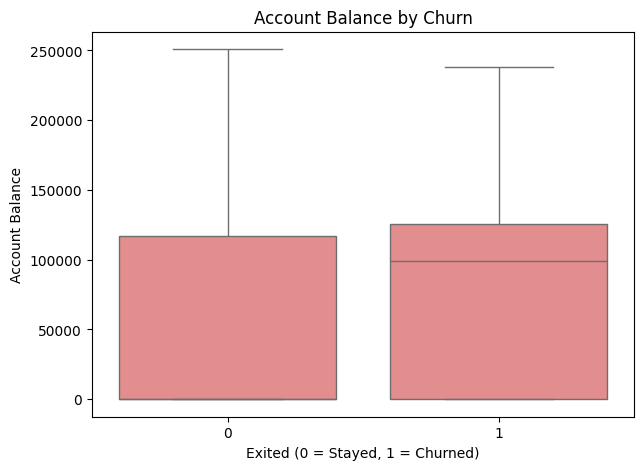

In [20]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x="Exited", y="Balance", color="lightcoral")

plt.title("Account Balance by Churn")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Account Balance")

plt.show()

The account balance distributions overlap between customers who stayed and those who churned. Both groups show a wide spread of balances, suggesting that balance alone may not clearly distinguish churned customers from retained customers.

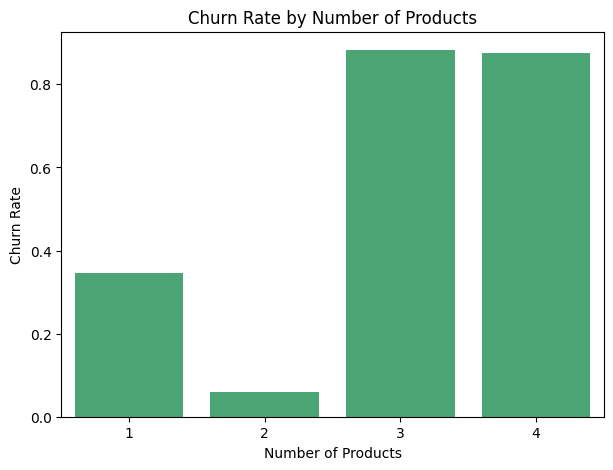

In [21]:
product_rate = df.groupby("NumOfProducts", as_index=False)["Exited"].mean()

plt.figure(figsize=(7, 5))

sns.barplot(data=product_rate, x="NumOfProducts", y="Exited", color="mediumseagreen")

plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate")

plt.show()

Churn rates vary substantially across the number of products. Customers with three or four products show very high churn rates, while customers with two products have a much lower churn rate. These results suggest an association between the number of products and churn, although group sizes should be considered when interpreting the rates.

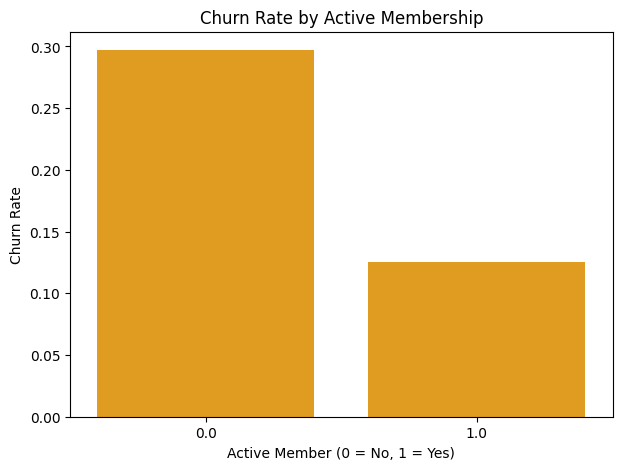

In [22]:
active_rate = df.groupby("IsActiveMember", as_index=False)["Exited"].mean()

plt.figure(figsize=(7, 5))

sns.barplot(data=active_rate, x="IsActiveMember", y="Exited", color="orange")

plt.title("Churn Rate by Active Membership")
plt.xlabel("Active Member (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate")

plt.show()

Inactive customers have a higher churn rate than active customers. This suggests that customer activity is associated with churn behavior, with inactive customers showing a greater tendency to leave the bank.

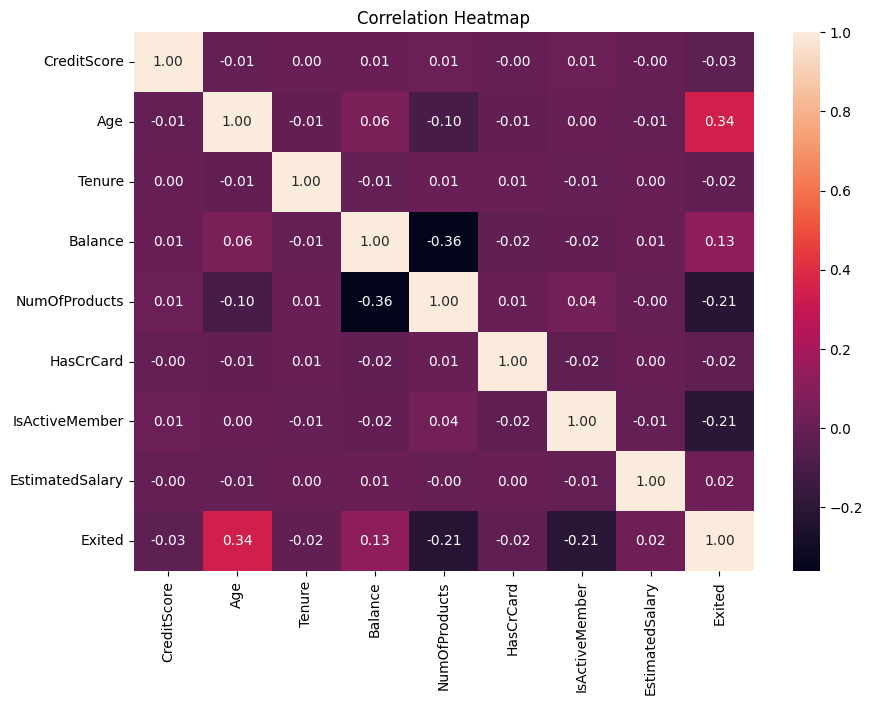

In [23]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Age shows the strongest positive correlation with Exited among the displayed features, followed by a weaker positive correlation with Balance. NumOfProducts and IsActiveMember show negative correlations with Exited. These correlations describe linear relationships and do not imply causation or establish feature importance for the prediction models.

In [24]:
X = df.drop("Exited", axis=1)
y = df["Exited"]


In [25]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97
1,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50
2,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69
3,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88
4,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83


In [26]:
le_geo = LabelEncoder()
le_gender = LabelEncoder()

X["Geography"] = le_geo.fit_transform(X["Geography"])
X["Gender"] = le_gender.fit_transform(X["Gender"])

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "SVM": SVC(
        class_weight="balanced"
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })
results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.743085   0.435948  0.728952  0.545601
1                  SVM  0.806465   0.528473  0.791953  0.633926
2                  KNN  0.847245   0.677514  0.530641  0.595150
3        Decision Tree  0.801072   0.530449  0.521334  0.525852
4          Naive Bayes  0.827431   0.651815  0.395905  0.492606
5        Random Forest  0.857000   0.729615  0.515034  0.603827
6    Gradient Boosting  0.863877   0.754964  0.528064  0.621451


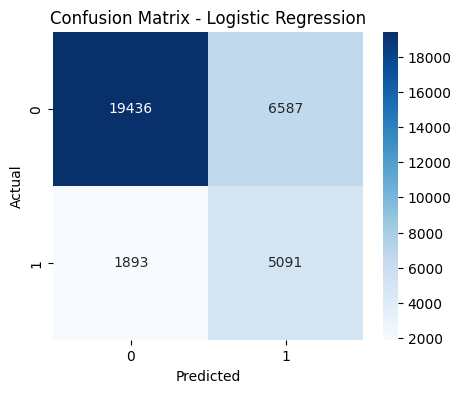

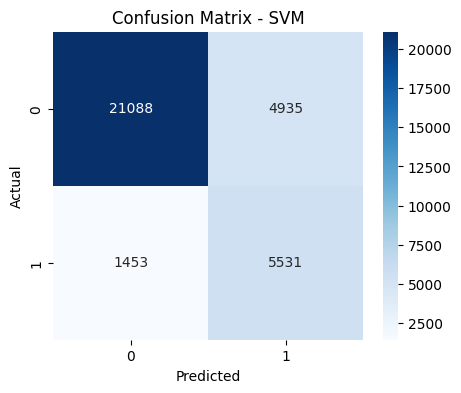

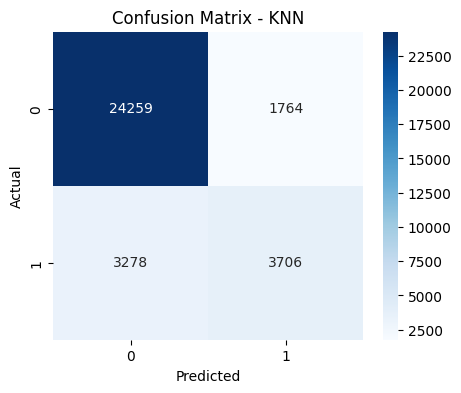

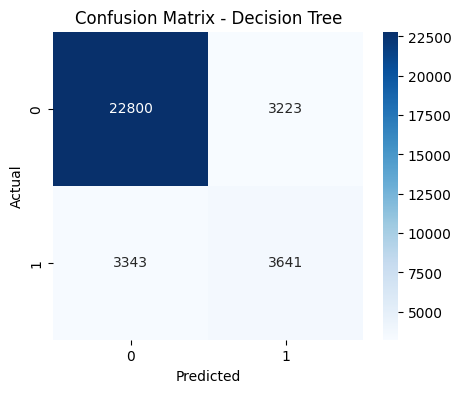

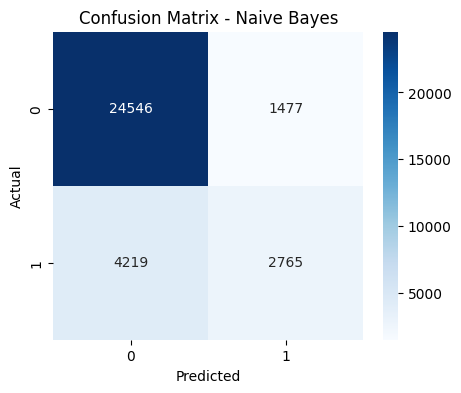

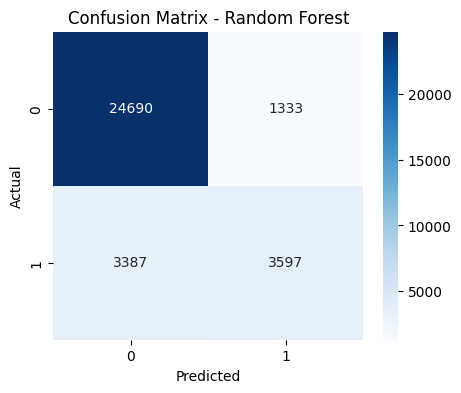

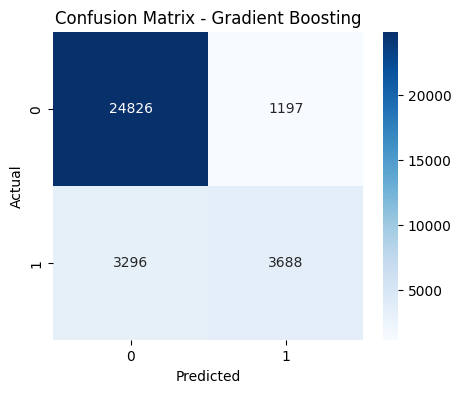

In [30]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [31]:
from sklearn.metrics import classification_report

for name, model in models.items():
    y_pred = model.predict(X_test)

    print("=" * 30)
    print(name)
    print("=" * 30)
    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.75      0.82     26023
           1       0.44      0.73      0.55      6984

    accuracy                           0.74     33007
   macro avg       0.67      0.74      0.68     33007
weighted avg       0.81      0.74      0.76     33007

SVM
              precision    recall  f1-score   support

           0       0.94      0.81      0.87     26023
           1       0.53      0.79      0.63      6984

    accuracy                           0.81     33007
   macro avg       0.73      0.80      0.75     33007
weighted avg       0.85      0.81      0.82     33007

KNN
              precision    recall  f1-score   support

           0       0.88      0.93      0.91     26023
           1       0.68      0.53      0.60      6984

    accuracy                           0.85     33007
   macro avg       0.78      0.73      0.75     33007
weighted avg       0.84      0.85      0.84   

In [33]:
from pathlib import Path
 
out_dir = Path("model_files")
out_dir.mkdir(exist_ok=True)
 
MODEL_FILES = {
    "Logistic Regression": "churn_model_logistic_regression.pkl",
    "SVM": "churn_model_svm.pkl",
    "KNN": "churn_model_knn.pkl",
    "Decision Tree": "churn_model_decision_tree.pkl",
    "Naive Bayes": "churn_model_naive_bayes.pkl",
    "Random Forest": "churn_model_random_forest.pkl",
    "Gradient Boosting": "churn_model_gradient_boosting.pkl",
}
 
for name, filename in MODEL_FILES.items():
    joblib.dump(models[name], out_dir / filename, compress=3)
 
joblib.dump(le_geo, out_dir / "geo_encoder.pkl")
joblib.dump(le_gender, out_dir / "gender_encoder.pkl")
joblib.dump(scaler, out_dir / "scaler.pkl")
 
for f in sorted(out_dir.glob("*.pkl")):
    print(f"{f.name:<42} {f.stat().st_size / 1_048_576:8.2f} MB")

churn_model_decision_tree.pkl                  0.69 MB
churn_model_gradient_boosting.pkl              0.04 MB
churn_model_knn.pkl                            6.42 MB
churn_model_logistic_regression.pkl            0.00 MB
churn_model_naive_bayes.pkl                    0.00 MB
churn_model_random_forest.pkl                 64.04 MB
churn_model_svm.pkl                            1.46 MB
gender_encoder.pkl                             0.00 MB
geo_encoder.pkl                                0.00 MB
scaler.pkl                                     0.00 MB


Model Selection Justification: Although Gradient Boosting achieved the highest accuracy (86.4%) and precision (75.5%), SVM was selected as the final model because it achieved the highest Recall (79.2%) and F1-score (0.634). In a churn prediction context, failing to identify a customer who will actually leave (False Negative) is more costly to the business than mistakenly flagging a loyal customer (False Positive) — since the retention team can simply follow up with the flagged customer at minimal cost. SVM's higher recall makes it more aligned with the business goal of minimizing missed at-risk customers.